## 라이브러리 로드

In [1]:
# 라이브러리 로드
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np
import scipy as sp

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.model_selection import GridSearchCV

## 데이터 로드

In [2]:
# 데이터 디렉토리 설정
data_dir = './data'

# 파일 경로 변환
train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

# 데이터 로드
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

# 데이터 확인
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


## 데이터 전처리

In [3]:
# date 컬럼의 값에서 6자리만 슬라이싱
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

# price의 통계 확인
train['price'].describe()

count    1.503500e+04
mean     5.406827e+05
std      3.715247e+05
min      7.800000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Density'>

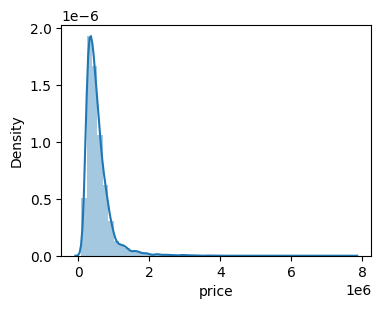

In [4]:
# price 분포 시각화
fig, ax = plt.subplots(figsize=(4, 3))
sns.distplot(train['price'])

In [5]:
# price 정규화
train['price'] = np.log1p(train['price'])

<Axes: >

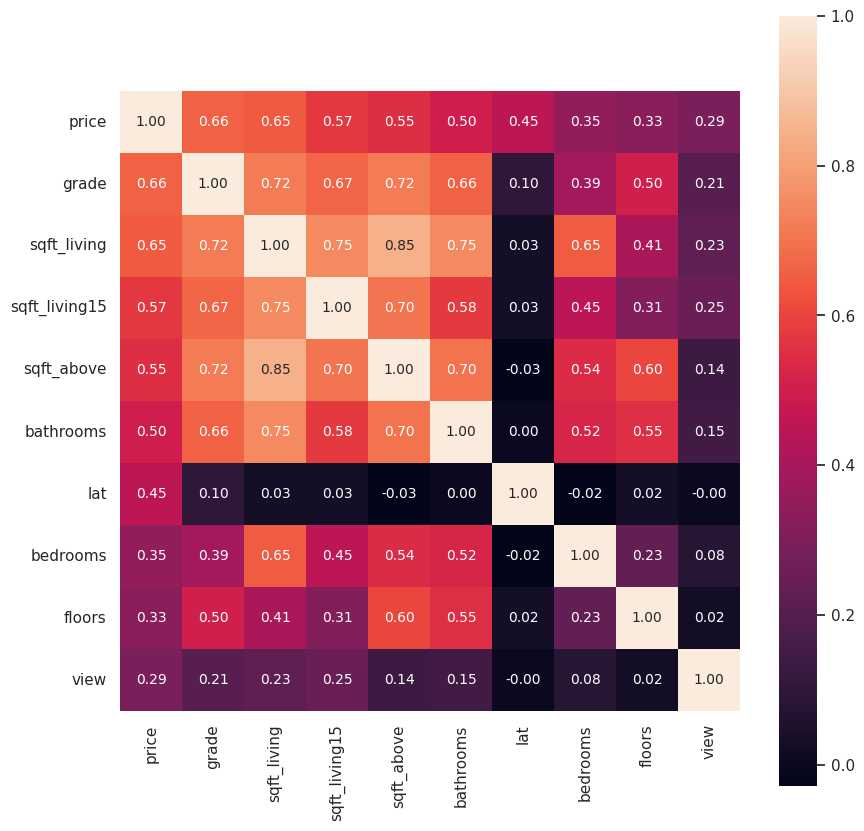

In [6]:
# price와 상관관계가 높은 상위 10개 변수 추출
# abs를 통해 양과 음 모두 확인
cor_abs = abs(train.corr(method='spearman'))
# 절대값이 큰 10개만 추출
cor_cols = cor_abs.nlargest(n=10, columns='price').index

# 10개 변수간 스피어만 상관계수 행렬 계산
cor = np.array(sp.stats.spearmanr(train[cor_cols].values))[0]

# 상관계수 heatmap 시각화
plt.figure(figsize=(10,10))
sns.set(font_scale=1)
sns.heatmap(cor, fmt='.2f', annot=True, square=True, annot_kws={'size' : 10},
                xticklabels=cor_cols.values, yticklabels=cor_cols.values)

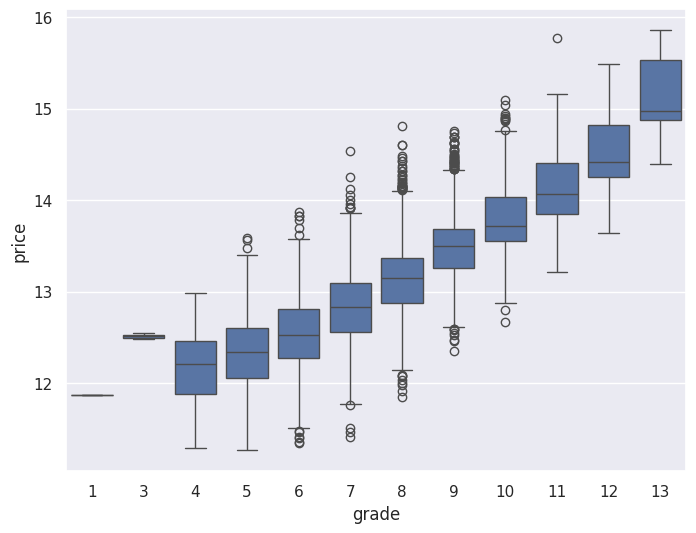

In [7]:
# grade와 price의 관계 시각화
data = pd.concat([train['price'], train['grade']], axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='grade', y='price', data=data)

In [8]:
# 그룹별 IQR 기반 이상치 제거 함수
def grade_IQR(df, target_col='price', group_col='grade'):
    # 정상 데이터 보관용 리스트
    keep_indices = []
    
    # group을 다시 쪼개 반복
    for grade_val, group in df.groupby(group_col):
        Q1 = group[target_col].quantile(0.25)
        Q3 = group[target_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 정상 데이터만 필터링
        valid_group = group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]
        
        # 리스트에 추가
        keep_indices.extend(valid_group.index)
    
    # 모든 정상 데이터만 추가 후 반환
    return df.loc[sorted(keep_indices)].reset_index(drop=True)

In [9]:
# 이상치 제거
train = grade_IQR(train, target_col='price', group_col='grade')

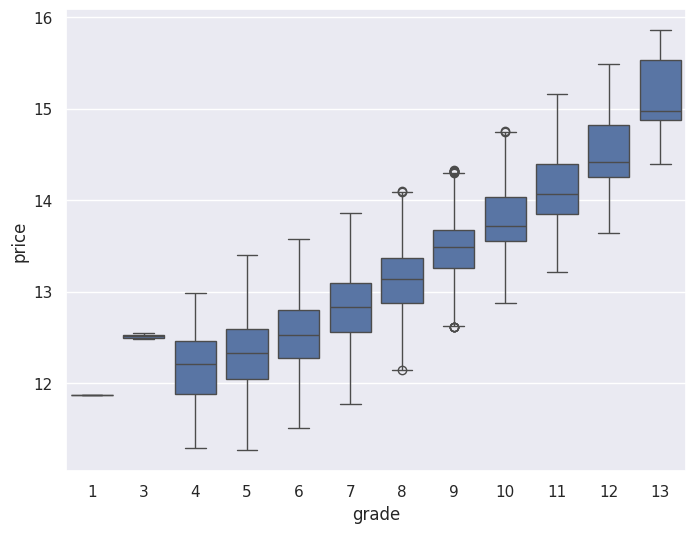

In [10]:
# 제거 후 관계 재확인
data = pd.concat([train['price'], train['grade']], axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='grade', y='price', data=data)

In [11]:
# 타켓 분리 및 기존 컬럼 제거
y = train['price']
del train['price']

# 데이터 통합
train_len = len(train)
data = pd.concat([train, test])

In [12]:
# id 컬럼 분리 및 제거
test_id = data['id'][train_len:]
del data['id']

# 한쪽으로 쏠린 컬럼 정규화
skew_columns = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']
for c in skew_columns:
    data[c] = np.log1p(data[c].values)

In [13]:
# 데이터 재분리
train = data.iloc[:train_len, :]
test = data.iloc[train_len:, :]

## 모델 평가

In [14]:
# rmse 평가지표 계산 함수
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

In [15]:
# 여러 모델의 성능(rmse) 비교 함수
def get_scores(models, train, y):
        df = {}

        for model in models:
            model_name = model.__class__.__name__
            X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=2026, test_size=0.2)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # 동일한 종류의 모델 사용시 중복 방지
            if model_name in df:
                model_name = model_name + str(models.index(model))
            df[model_name] = rmse(y_test, y_pred)
            score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=True)
            
        return (score_df)    

In [ ]:
def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=-1):
    # GridSearchCV 모델 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error',
                              cv=5, verbose=verbose, n_jobs=n_jobs)
    
    # 모델 학습
    grid_model.fit(train, y)
    
    # 결과 추출
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']
    
    # 데이터프레임 생성 및 RMSE 계산
    results = pd.DataFrame(params)
    results['score'] = score
    
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    
    # RMSE 기준 오름차순 정렬
    results = results.sort_values(by='RMSLE')
    
    return results

In [19]:
# 하이퍼 파라미터 세팅
param_grid = {
    'learning_rate' : [0.015],
    'n_estimators': [1600],
    'max_depth': [14],
}

In [20]:
# 모델 객체 생성 및 그리드 서치 수행
model = LGBMRegressor(random_state=2026)
my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2294
[LightGBM] [Info] Number of data points in the train set: 11924, number of used features: 19
[LightGBM] [Info] Start training from score 13.043419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 11925, number of used features: 19
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2327
[LightGBM] [Info] Start training from score 

,learning_rate,max_depth,n_estimators,score,RMSLE
0,0.015,14,1600,-0.024782,0.157423


In [21]:
# 모델 성능 비교
lgb0 = LGBMRegressor(learning_rate=0.015, max_depth=7, n_estimators=1600, random_state=2026)
lgb1 = LGBMRegressor(learning_rate=0.015, max_depth=14, n_estimators=1600, random_state=2026)
lgb2 = LGBMRegressor(learning_rate=0.015, max_depth=7, n_estimators=1200, random_state=2026)
lgb3 = LGBMRegressor(learning_rate=0.015, max_depth=14, n_estimators=1200, random_state=2026)
vote = VotingRegressor(estimators=[('lgbm0', lgb0), ('lgbm1', lgb1), ('lgbm2', lgb2), ('lgbm3', lgb3)])
get_scores([lgb0, lgb1, lgb2, lgb3, vote], train, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2297
[LightGBM] [Info] Number of data points in the train set: 11924, number of used features: 19
[LightGBM] [Info] Start training from score 13.041485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,RMSE
LGBMRegressor1,102157.079899
VotingRegressor,102641.493809
LGBMRegressor,102738.900308
LGBMRegressor3,102995.915443
LGBMRegressor2,103684.388988


## 결과 제출

In [22]:
def save_submission(model, train, y, test, model_name, rmse=None):
    model.fit(train, y)
    prediction = model.predict(test)
    prediction = np.expm1(prediction)
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/submission_{}_RMSE_{}.csv'.format(data_dir, model_name, rmse)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

rmse가 가장 낮은 lgbm과 ensemble방식의 voting을 저장하였다.

In [27]:
save_submission(lgb1, train, y, test, 'lgbm', rmse='102157')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2335
[LightGBM] [Info] Number of data points in the train set: 14906, number of used features: 19
[LightGBM] [Info] Start training from score 13.041152
./data/submission_lgbm_RMSE_102157.csv saved!


In [28]:
save_submission(vote, train, y, test, 'voting', rmse='102641')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2335
[LightGBM] [Info] Number of data points in the train set: 14906, number of used features: 19
[LightGBM] [Info] Start training from score 13.041152
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

![](./result.png).

# 회고
주어진 feature 중 상관관계에 따라 구분하여 가장 높은 grade값의 이상치를 IQR을 통해 제거해보았다.   처음에는 여러 feature들을 추가하고 삭제하기 바빳는데 그 결과가 좋지않았다.   이에 기존에 있던 feature들을 수정해보기로 하고 시간관계상 가장 큰 상관관계를 보인 grade만 이상치를 제거해주었다.  그런데 결과를 보면 public은 줄었지만 private는 증가하였다.   값들을 제거하며 overfitting이 일어난 것같고 이번엔 IQR을 통해 지웠지만 생각보다 많은 데이터가 날라갔다.   다음에는 범위를 넓게잡고 이상치라 구분하는 값들을 줄이고 다른 overfitting을 방지하는 기법을 써보면 좋을 것같다.   하이퍼 파라미터를 다루는데 n_estimator가 크게 늘리자 개당 시간이 너무 오래걸렸고 이때문에 노트북에서 파라미터를 하나씩만 다루게 되었다.   그런데 생각보다 파라미터가 미치는 영향이 그렇게 크진않았고 feature들을 다룬 후에 이에 맞게 조절하는 정도지 처음부터 그것만 보고 하는게 별로라는 것을 알 수 있었다.